# Análise Exploratória de Dados (EDA)
## Sleep Health and Lifestyle Dataset

**Disciplina:** APEX — 2º Bimestre &nbsp;|&nbsp; **Atividade 05**
**Professor:** Alan Gonçalves
**Grupo:** _CTRL + ALT + DELAS_
**Data:** _19/05/2026_

---

### Sobre o dataset

O *Sleep Health and Lifestyle Dataset* reúne dados sobre hábitos de sono e estilo
de vida de aproximadamente 400 indivíduos. Cada linha é uma pessoa; as colunas
trazem variáveis demográficas, de saúde e comportamentais:

| Variável | Tipo | Descrição |
|---|---|---|
| `Person ID` | Numérica | Identificador único do indivíduo |
| `Gender` | Categórica | Gênero (Male / Female) |
| `Age` | Numérica | Idade em anos |
| `Occupation` | Categórica | Profissão |
| `Sleep Duration` | Numérica | Horas de sono por noite |
| `Quality of Sleep` | Numérica (1–10) | Qualidade subjetiva do sono |
| `Physical Activity Level` | Numérica | Minutos de atividade física por dia |
| `Stress Level` | Numérica (1–10) | Nível de estresse autorrelatado |
| `BMI Category` | Categórica | Categoria de IMC |
| `Blood Pressure` | Texto | Pressão arterial (sistólica/diastólica) |
| `Heart Rate` | Numérica | Frequência cardíaca em repouso (bpm) |
| `Daily Steps` | Numérica | Passos por dia |
| `Sleep Disorder` | Categórica | Distúrbio do sono (None / Insomnia / Sleep Apnea) |

### Objetivo

Conduzir uma EDA completa, percorrendo cinco etapas: **(1)** carregamento e
inspeção inicial, **(2)** qualidade dos dados, **(3)** análise univariada,
**(4)** análise bivariada e **(5)** síntese interpretativa com pelo menos 3
insights conectando os achados a uma narrativa coerente.


## 0. Preparação do ambiente

Importamos as bibliotecas usadas em toda a análise: `pandas` para manipulação
tabular, `numpy` para suporte numérico, e `matplotlib`/`seaborn` para as
visualizações. Também definimos um estilo visual padrão para os gráficos.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo visual padrão para todos os gráficos
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", None)
print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## 1. Carregamento e inspeção inicial

Para carregar o dataset no Google Colab, baixe o arquivo `Sleep_health_and_lifestyle_dataset.csv` da página do Kaggle para o seu computador. Ao executar a célula abaixo, um botão de upload aparecerá: selecione o arquivo baixado.

In [ ]:
# Carregamento do dataset
# Execute esta célula e selecione o CSV baixado do Kaggle.
from google.colab import files
import io

uploaded = files.upload()
Sleep_health_and_lifestyle_dataset = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[Sleep_health_and_lifestyle_dataset]))
print(f"Arquivo '{Sleep_health_and_lifestyle_dataset}' carregado com sucesso!")

Saving Sleep_health_and_lifestyle_dataset.csv to Sleep_health_and_lifestyle_dataset (1).csv
Arquivo 'Sleep_health_and_lifestyle_dataset (1).csv' carregado com sucesso!


### Inspeção inicial

Com o dataset carregado, fazemos a primeira inspeção: dimensões, primeiras
linhas, tipos das variáveis e estatísticas descritivas. Essa etapa serve para
entender **o que** temos em mãos antes de qualquer análise mais profunda.

In [ ]:
# Dimensões do dataset (linhas, colunas)
print(f"O dataset possui {df.shape[0]} linhas e {df.shape[1]} colunas.")

O dataset possui 374 linhas e 13 colunas.


In [ ]:
# Primeiras 5 observações
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [ ]:
# Últimas 5 observações
df.tail()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
373,374,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [ ]:
# Tipos de dados e contagem de valores não-nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [ ]:
# Estatísticas descritivas das variáveis numéricas
df.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [ ]:
# Estatísticas descritivas das variáveis categóricas
df.describe(include="object")

,Gender,Occupation,BMI Category,Blood Pressure,Sleep Disorder
count,374,374,374,374,155
unique,2,11,4,25,2
top,Male,Nurse,Normal,130/85,Sleep Apnea
freq,189,73,195,99,78


**Leitura inicial:** o dataset tem **374 linhas** e **13 colunas**. A maioria
das variáveis é numérica (idade, duração do sono, passos etc.), mas há quatro
variáveis categóricas relevantes — `Gender`, `Occupation`, `BMI Category` e
`Sleep Disorder` — e a coluna `Blood Pressure`, que está armazenada como **texto**
no formato `sistólica/diastólica`. Esses pontos serão tratados na próxima etapa.

## 2. Qualidade dos dados

Aqui investigamos **valores ausentes, duplicatas e inconsistências**, garantindo
que a base esteja limpa e confiável antes das análises estatísticas.

In [ ]:
# Contagem de valores ausentes por coluna
ausentes = df.isnull().sum()
print("Valores ausentes por coluna:\n")
print(ausentes)
print(f"\nTotal de células ausentes: {df.isnull().sum().sum()}")

Valores ausentes por coluna:

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

Total de células ausentes: 219


**Observação importante sobre `Sleep Disorder`:**
A coluna `Sleep Disorder` apresenta 219 valores nulos (`NaN`). Isso **não é um erro
de coleta**: esses `NaN` representam pessoas que **não possuem** distúrbio do sono.
Portanto, em vez de removê-los, vamos substituí-los pela categoria explícita
`"None"`. Tratar esses valores como dados faltantes e descartá-los eliminaria
quase 60% da amostra — um erro grave de interpretação.

In [ ]:
# Trata os NaN de Sleep Disorder como categoria válida: "None"
df["Sleep Disorder"] = df["Sleep Disorder"].fillna("None")

print("Distribuição de 'Sleep Disorder' após o tratamento:")
print(df["Sleep Disorder"].value_counts())
print(f"\nValores ausentes restantes no dataset: {df.isnull().sum().sum()}")

Distribuição de 'Sleep Disorder' após o tratamento:
Sleep Disorder
None           219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64

Valores ausentes restantes no dataset: 0


In [ ]:
# Verifica linhas totalmente duplicadas
n_dup = df.duplicated().sum()
print(f"Linhas totalmente duplicadas: {n_dup}")

# Verifica duplicatas de conteúdo ignorando o identificador 'Person ID'
n_dup_conteudo = df.drop(columns="Person ID").duplicated().sum()
print(f"Linhas com conteúdo idêntico (ignorando 'Person ID'): {n_dup_conteudo}")

Linhas totalmente duplicadas: 0
Linhas com conteúdo idêntico (ignorando 'Person ID'): 242


Não há linhas **totalmente** idênticas (o `Person ID` é único para cada uma).
Porém, ao ignorar o `Person ID`, encontramos registros com exatamente o mesmo
conteúdo — provavelmente o mesmo perfil de pessoa cadastrado mais de uma vez.
Como o `Person ID` é apenas um identificador sequencial sem valor analítico e o
volume é pequeno, optamos por **manter os registros** para preservar o tamanho da
amostra, apenas documentando a observação. Em seguida, removemos a coluna
`Person ID`, que não contribui para a análise.

In [ ]:
# Remove a coluna identificadora, que não tem valor analítico
df = df.drop(columns="Person ID")
print("Coluna 'Person ID' removida.")
print(f"Colunas atuais ({df.shape[1]}): {list(df.columns)}")

Coluna 'Person ID' removida.
Colunas atuais (12): ['Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps', 'Sleep Disorder']


### Tratando a coluna `Blood Pressure`

A pressão arterial está como texto (`"120/80"`). Para analisá-la numericamente,
separamos em duas colunas: `Systolic_BP` (sistólica) e `Diastolic_BP`
(diastólica).

In [ ]:
# Separa Blood Pressure em sistólica e diastólica
bp = df["Blood Pressure"].str.split("/", expand=True)
df["Systolic_BP"] = pd.to_numeric(bp[0], errors="coerce")
df["Diastolic_BP"] = pd.to_numeric(bp[1], errors="coerce")

print("Colunas 'Systolic_BP' e 'Diastolic_BP' criadas.")
df[["Blood Pressure", "Systolic_BP", "Diastolic_BP"]].head()

Colunas 'Systolic_BP' e 'Diastolic_BP' criadas.


,Blood Pressure,Systolic_BP,Diastolic_BP
0,126/83,126,83
1,125/80,125,80
2,125/80,125,80
3,140/90,140,90
4,140/90,140,90


### Verificando inconsistências nas categorias

Datasets reais costumam ter categorias escritas de formas diferentes. Vamos
inspecionar `BMI Category`.

In [ ]:
# Inspeciona as categorias de IMC
print("Categorias de IMC encontradas:")
print(df["BMI Category"].value_counts())

Categorias de IMC encontradas:
BMI Category
Normal           195
Overweight       148
Normal Weight     21
Obese             10
Name: count, dtype: int64


Note que aparecem **`Normal`** e **`Normal Weight`** — são a mesma categoria
escrita de duas maneiras. Vamos padronizar tudo para `Normal`.

In [ ]:
# Padroniza "Normal Weight" -> "Normal"
df["BMI Category"] = df["BMI Category"].replace({"Normal Weight": "Normal"})
print("Categorias de IMC após padronização:")
print(df["BMI Category"].value_counts())

Categorias de IMC após padronização:
BMI Category
Normal        216
Overweight    148
Obese          10
Name: count, dtype: int64


In [ ]:
# Resumo final da limpeza
print("=== RESUMO DA LIMPEZA ===")
print(f"Linhas...................: {df.shape[0]}")
print(f"Colunas..................: {df.shape[1]}")
print(f"Valores ausentes.........: {df.isnull().sum().sum()}")
print(f"Duplicatas totais........: {df.duplicated().sum()}")
print("\nDataset limpo e pronto para análise!")

=== RESUMO DA LIMPEZA ===
Linhas...................: 374
Colunas..................: 14
Valores ausentes.........: 0
Duplicatas totais........: 242

Dataset limpo e pronto para análise!


## 3. Análise univariada

A análise univariada estuda **uma variável por vez**. Para variáveis numéricas
observamos distribuições e medidas de tendência central e dispersão; para
categóricas, observamos frequências.

### 3.1 Variáveis numéricas — medidas resumo

In [ ]:
# Seleciona as colunas numéricas de interesse
colunas_num = ["Age", "Sleep Duration", "Quality of Sleep",
               "Physical Activity Level", "Stress Level",
               "Heart Rate", "Daily Steps", "Systolic_BP", "Diastolic_BP"]

# Medidas de tendência central e dispersão
resumo = df[colunas_num].agg(["mean", "median", "std", "min", "max"]).T
resumo.columns = ["Média", "Mediana", "Desvio-padrão", "Mínimo", "Máximo"]
resumo.round(2)

,Média,Mediana,Desvio-padrão,Mínimo,Máximo
Age,42.18,43.0,8.67,27.0,59.0
Sleep Duration,7.13,7.2,0.80,5.8,8.5
Quality of Sleep,7.31,7.0,1.20,4.0,9.0
Physical Activity Level,59.17,60.0,20.83,30.0,90.0
Stress Level,5.39,5.0,1.77,3.0,8.0
Heart Rate,70.17,70.0,4.14,65.0,86.0
Daily Steps,6816.84,7000.0,1617.92,3000.0,10000.0
Systolic_BP,128.55,130.0,7.75,115.0,142.0
Diastolic_BP,84.65,85.0,6.16,75.0,95.0


### 3.2 Variáveis numéricas — histogramas

Os histogramas mostram o **formato da distribuição** de cada variável numérica.

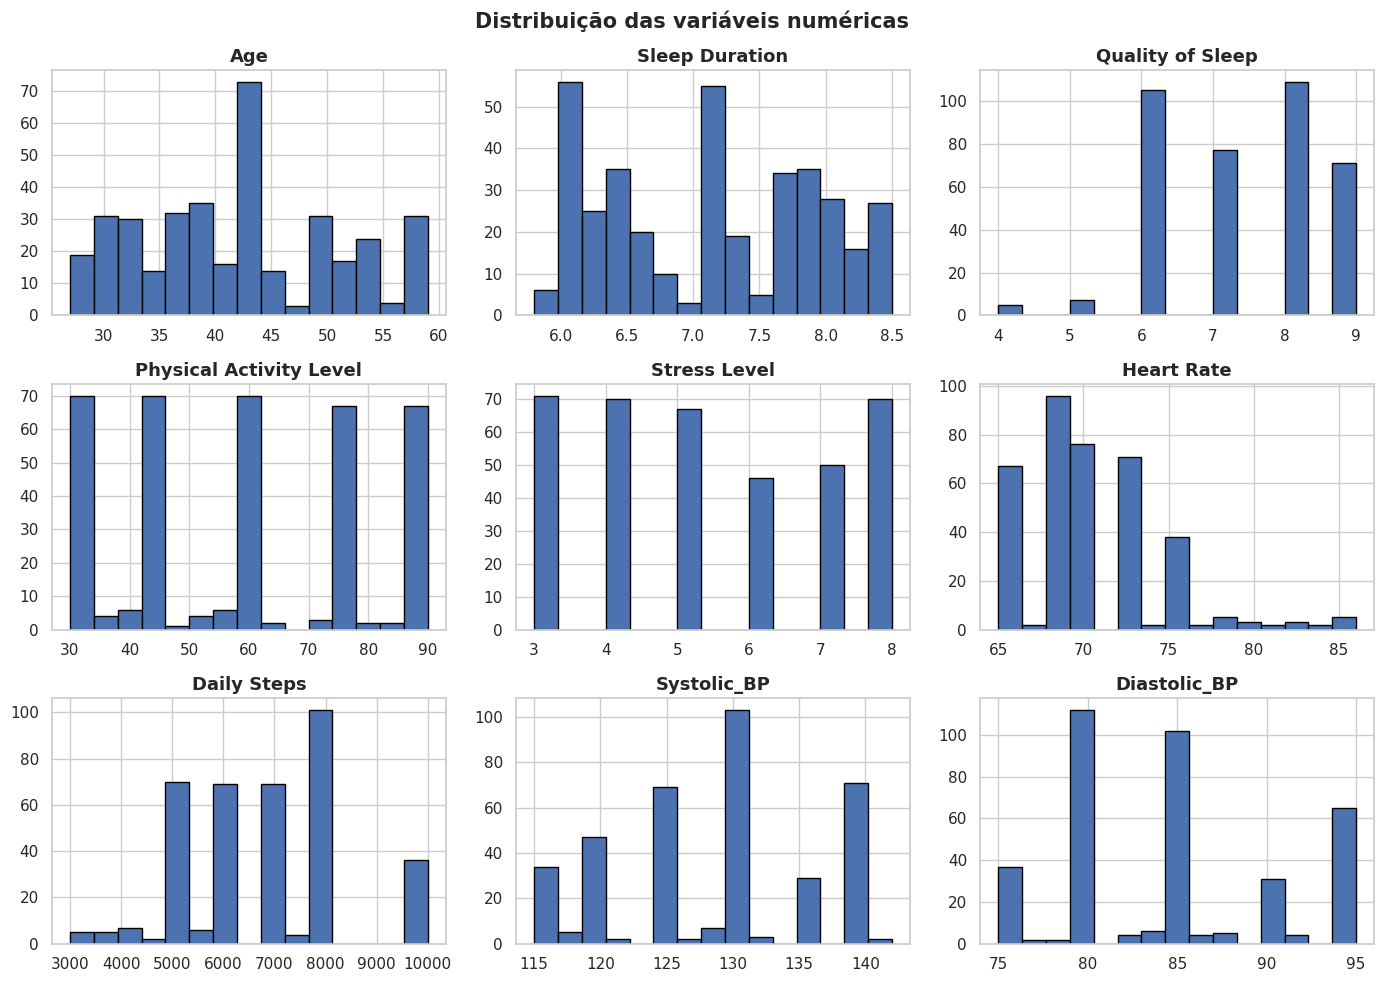

In [ ]:
# Histogramas de todas as variáveis numéricas
df[colunas_num].hist(figsize=(14, 10), bins=15, edgecolor="black", color="#4C72B0")
plt.suptitle("Distribuição das variáveis numéricas", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

### 3.3 Variáveis numéricas — boxplots

Os boxplots ajudam a visualizar **mediana, dispersão e possíveis outliers**.

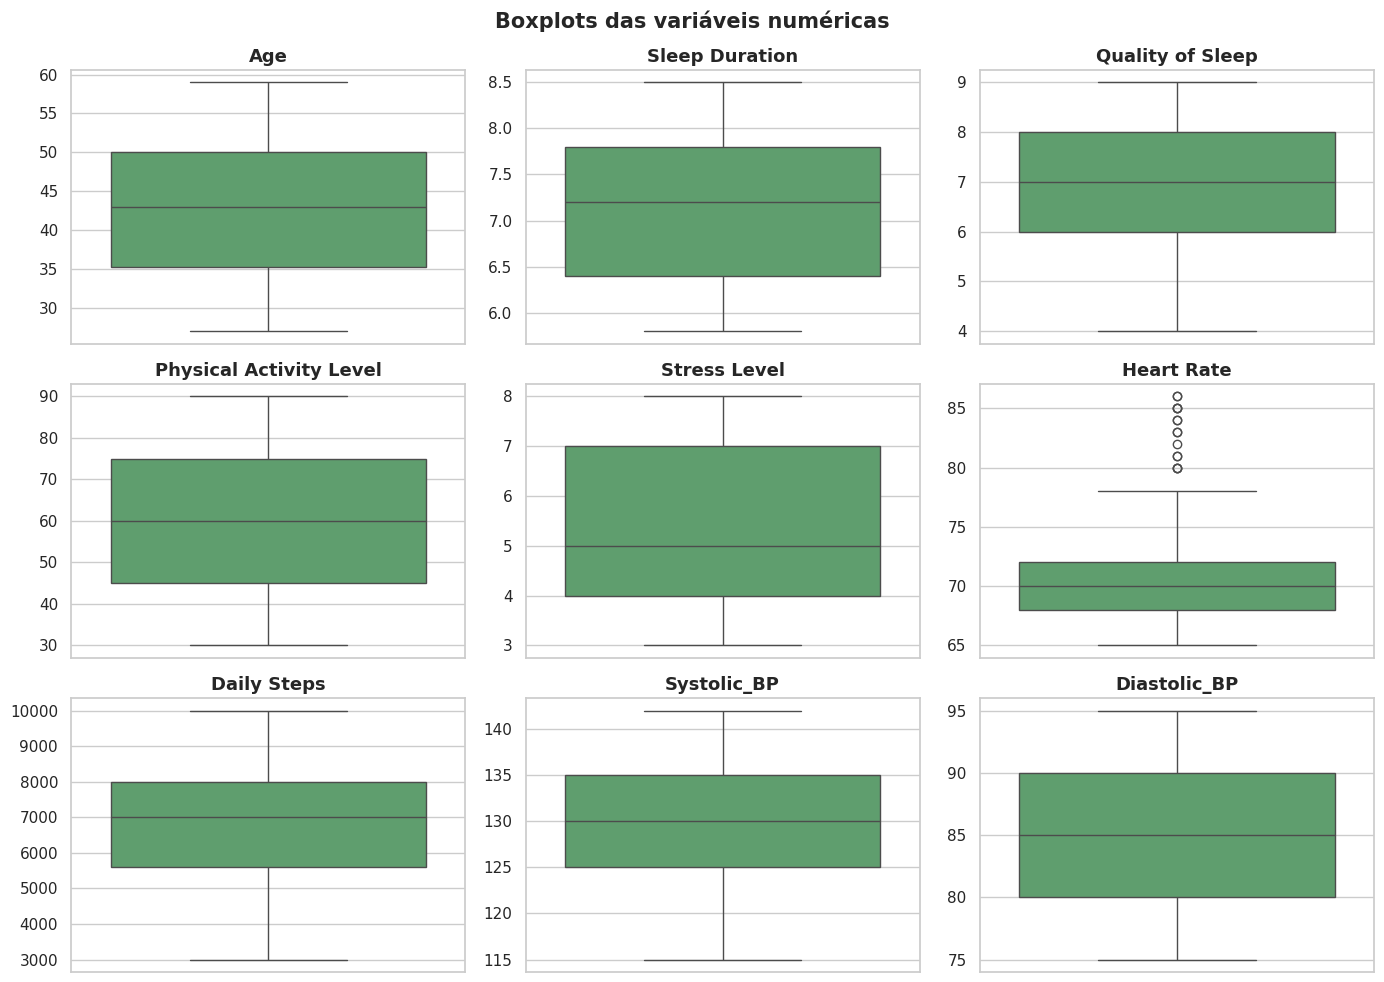

In [ ]:
# Boxplots individuais para cada variável numérica
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.flatten(), colunas_num):
    sns.boxplot(y=df[col], ax=ax, color="#55A868")
    ax.set_title(col)
    ax.set_ylabel("")
plt.suptitle("Boxplots das variáveis numéricas", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

### 3.4 Variáveis categóricas — frequências

Para as variáveis categóricas, contamos a frequência de cada categoria.

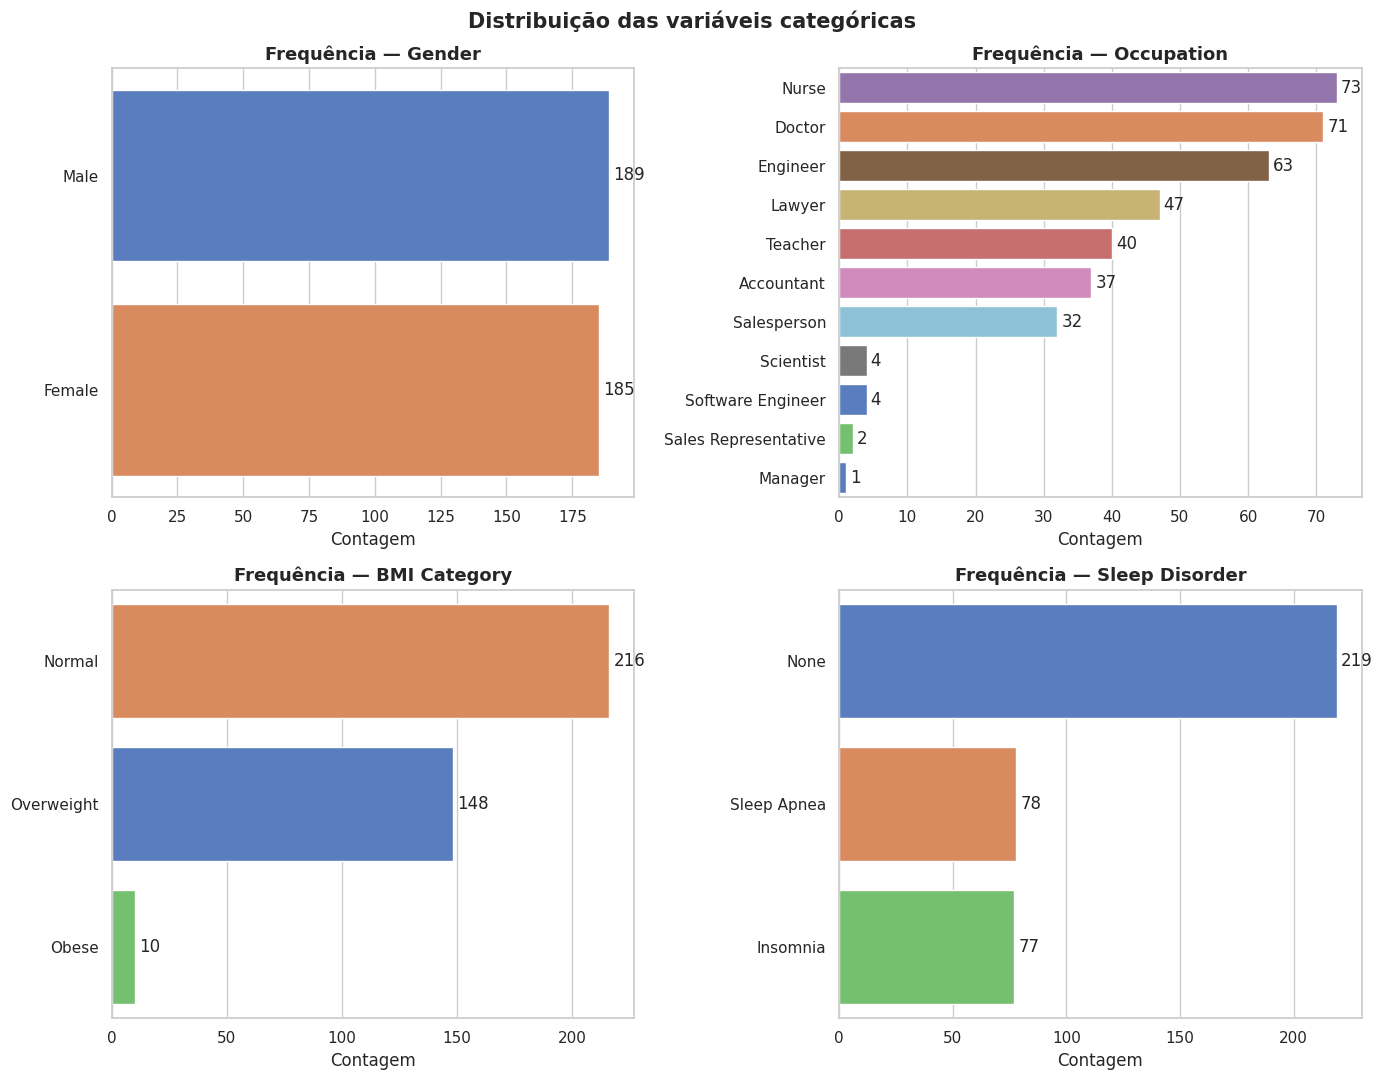

In [ ]:
# Variáveis categóricas
colunas_cat = ["Gender", "Occupation", "BMI Category", "Sleep Disorder"]

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for ax, col in zip(axes.flatten(), colunas_cat):
    ordem = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=ordem, ax=ax, palette="muted", hue=col, legend=False)
    ax.set_title(f"Frequência — {col}")
    ax.set_xlabel("Contagem")
    ax.set_ylabel("")
    # Rótulos com a contagem em cada barra
    for container in ax.containers:
        ax.bar_label(container, padding=3)
plt.suptitle("Distribuição das variáveis categóricas", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# Tabela de frequências detalhada (contagem e percentual)
for col in colunas_cat:
    print(f"\n=== {col} ===")
    cont = df[col].value_counts()
    perc = (df[col].value_counts(normalize=True) * 100).round(1)
    print(pd.DataFrame({"Contagem": cont, "Percentual (%)": perc}))


=== Gender ===
        Contagem  Percentual (%)
Gender                          
Male         189            50.5
Female       185            49.5

=== Occupation ===
                      Contagem  Percentual (%)
Occupation                                    
Nurse                       73            19.5
Doctor                      71            19.0
Engineer                    63            16.8
Lawyer                      47            12.6
Teacher                     40            10.7
Accountant                  37             9.9
Salesperson                 32             8.6
Scientist                    4             1.1
Software Engineer            4             1.1
Sales Representative         2             0.5
Manager                      1             0.3

=== BMI Category ===
              Contagem  Percentual (%)
BMI Category                          
Normal             216            57.8
Overweight         148            39.6
Obese               10             2.7

===

**Leitura da análise univariada:**

- A **idade** concentra-se aproximadamente entre 27 e 59 anos — é uma amostra de
  adultos em idade ativa.
- A **duração do sono** gira em torno de 7 horas, e a **qualidade do sono** (escala
  1–10) tem mediana alta, indicando que boa parte da amostra dorme razoavelmente
  bem.
- O **nível de estresse** varia bastante de pessoa para pessoa.
- Em `Gender`, a amostra é bem equilibrada entre homens e mulheres.
- As profissões mais frequentes são **Nurse**, **Doctor** e **Engineer**.
- Quanto a `Sleep Disorder`, a maioria não tem distúrbio (`None`), mas há um número
  relevante de casos de **Insomnia** e **Sleep Apnea**.

## 4. Análise bivariada

A análise bivariada investiga **relações entre pares de variáveis**, usando
correlações e gráficos comparativos.

### 4.1 Matriz de correlação (variáveis numéricas)

A correlação de Pearson mede a força e a direção da relação linear entre duas
variáveis numéricas (varia de -1 a +1).

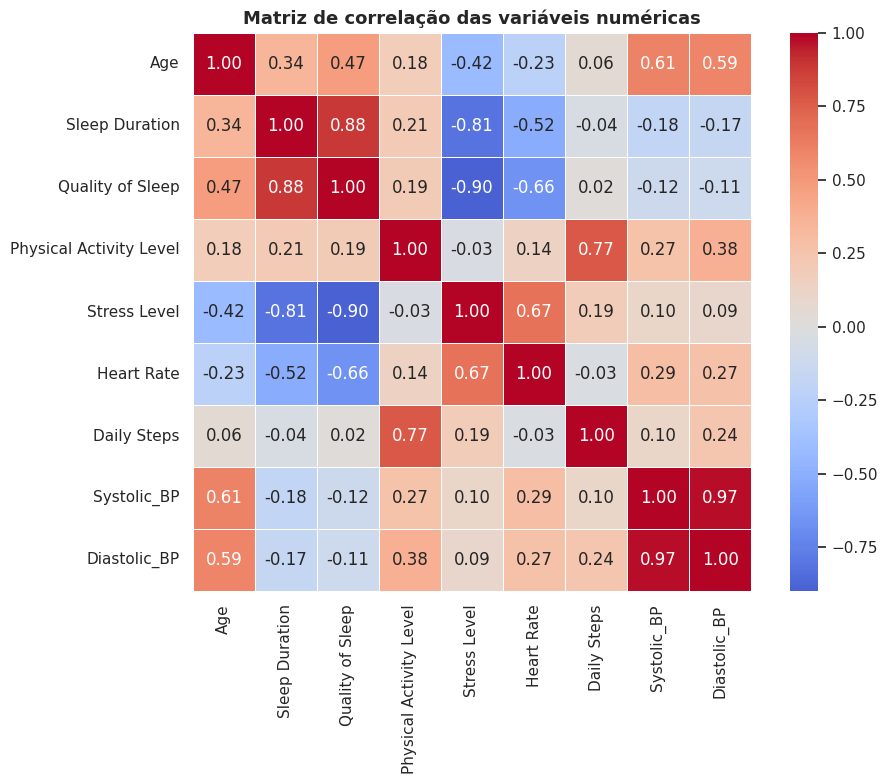

In [ ]:
# Matriz de correlação
corr = df[colunas_num].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=.5)
plt.title("Matriz de correlação das variáveis numéricas")
plt.tight_layout()
plt.show()

O destaque da matriz é a relação entre **estresse, qualidade e duração do
sono**. Vamos explorá-la com mais detalhe.

### 4.2 Estresse vs. Qualidade do sono

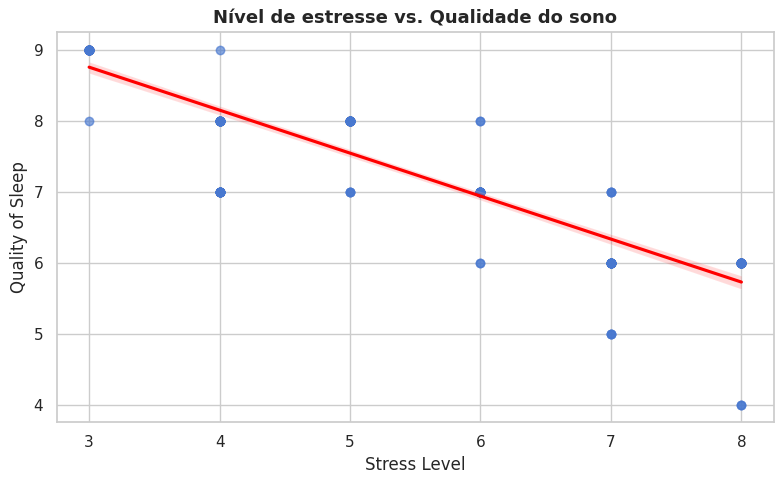

Correlação (Estresse x Qualidade do sono): -0.90


In [ ]:
# Relação entre nível de estresse e qualidade do sono
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x="Stress Level", y="Quality of Sleep",
            scatter_kws={"alpha": 0.4}, line_kws={"color": "red"})
plt.title("Nível de estresse vs. Qualidade do sono")
plt.tight_layout()
plt.show()

r = df["Stress Level"].corr(df["Quality of Sleep"])
print(f"Correlação (Estresse x Qualidade do sono): {r:.2f}")

### 4.3 Duração do sono vs. Qualidade do sono

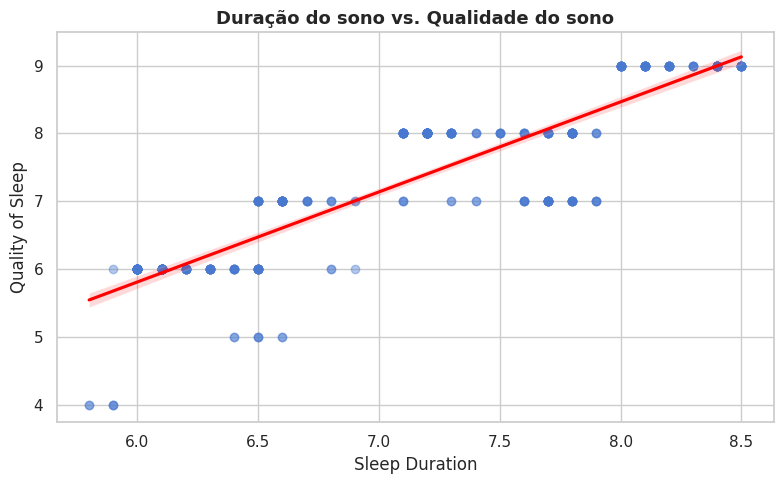

Correlação (Duração x Qualidade do sono): 0.88


In [ ]:
# Relação entre duração e qualidade do sono
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x="Sleep Duration", y="Quality of Sleep",
            scatter_kws={"alpha": 0.4}, line_kws={"color": "red"})
plt.title("Duração do sono vs. Qualidade do sono")
plt.tight_layout()
plt.show()

r = df["Sleep Duration"].corr(df["Quality of Sleep"])
print(f"Correlação (Duração x Qualidade do sono): {r:.2f}")

### 4.4 Qualidade do sono por categoria de IMC

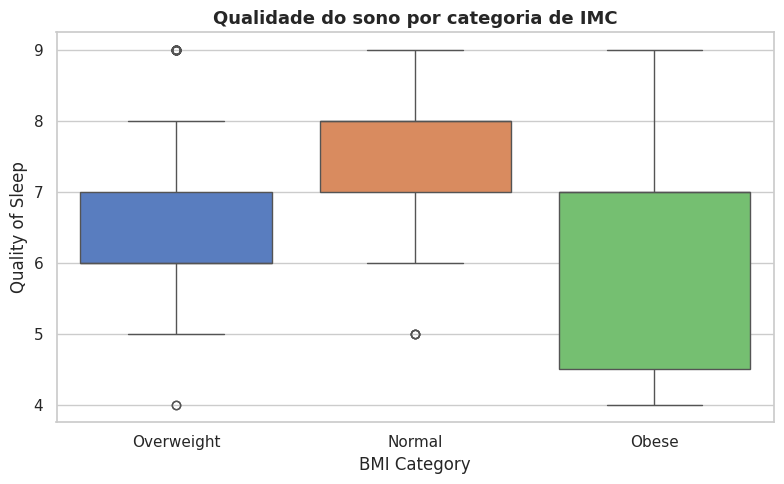

In [ ]:
# Qualidade do sono em função da categoria de IMC
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="BMI Category", y="Quality of Sleep",
            hue="BMI Category", palette="muted", legend=False)
plt.title("Qualidade do sono por categoria de IMC")
plt.tight_layout()
plt.show()

### 4.5 Distúrbios do sono por categoria de IMC

Aqui cruzamos duas variáveis categóricas para ver se o IMC se associa à presença
de distúrbios do sono.

Distribuição (%) de distúrbios do sono por categoria de IMC:

Sleep Disorder  Insomnia  None  Sleep Apnea
BMI Category                               
Normal               4.2  92.6          3.2
Obese               40.0   0.0         60.0
Overweight          43.2  12.8         43.9


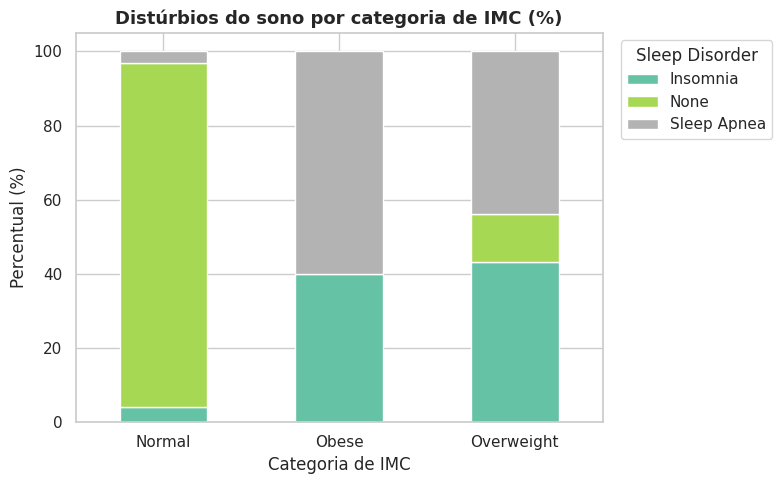

In [ ]:
# Tabela cruzada (proporção) entre IMC e distúrbio do sono
tab = pd.crosstab(df["BMI Category"], df["Sleep Disorder"], normalize="index") * 100
print("Distribuição (%) de distúrbios do sono por categoria de IMC:\n")
print(tab.round(1))

tab.plot(kind="bar", stacked=True, figsize=(8, 5), colormap="Set2")
plt.title("Distúrbios do sono por categoria de IMC (%)")
plt.ylabel("Percentual (%)")
plt.xlabel("Categoria de IMC")
plt.xticks(rotation=0)
plt.legend(title="Sleep Disorder", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

### 4.6 Duração do sono por gênero

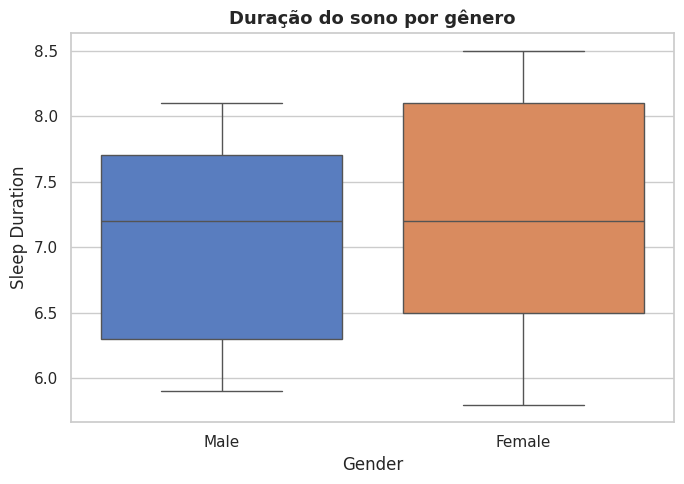

        mean  median   std
Gender                    
Female  7.23     7.2  0.88
Male    7.04     7.2  0.69


In [ ]:
# Comparação da duração do sono entre gêneros
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="Gender", y="Sleep Duration",
            hue="Gender", palette="muted", legend=False)
plt.title("Duração do sono por gênero")
plt.tight_layout()
plt.show()

print(df.groupby("Gender")["Sleep Duration"].agg(["mean", "median", "std"]).round(2))

### 4.7 Qualidade do sono por profissão

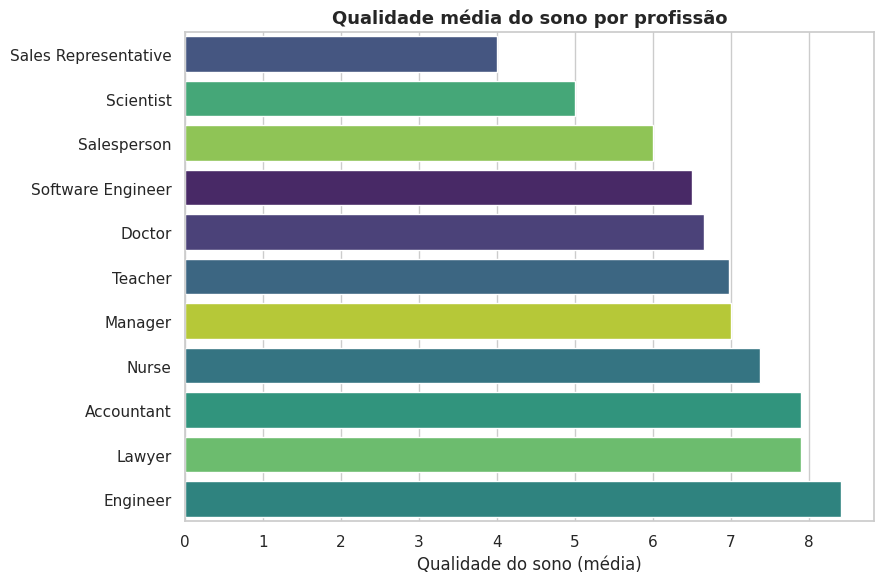

In [ ]:
# Qualidade média do sono por profissão (ordenada)
ordem_prof = df.groupby("Occupation")["Quality of Sleep"].mean().sort_values().index

plt.figure(figsize=(9, 6))
sns.barplot(data=df, y="Occupation", x="Quality of Sleep",
            order=ordem_prof, hue="Occupation", palette="viridis", legend=False,
            errorbar=None)
plt.title("Qualidade média do sono por profissão")
plt.xlabel("Qualidade do sono (média)")
plt.ylabel("")
plt.tight_layout()
plt.show()

**Leitura da análise bivariada:**

- **Estresse e qualidade do sono** têm forte correlação **negativa**: quanto maior
  o estresse, pior tende a ser o sono.
- **Duração e qualidade do sono** caminham juntas (correlação **positiva**): quem
  dorme mais horas tende a avaliar melhor a qualidade do sono.
- A **categoria de IMC** parece se relacionar tanto com a qualidade do sono quanto
  com a presença de distúrbios — pessoas fora da faixa `Normal` concentram mais
  casos de distúrbio.
- A **profissão** está associada a diferenças marcantes na qualidade do sono.

## 5. Síntese interpretativa

A seguir, conectamos os achados visuais e estatísticos em uma narrativa coerente.
Antes, calculamos alguns números que sustentam os insights.

In [ ]:
# Números de apoio para a síntese
print("APOIO QUANTITATIVO PARA OS INSIGHTS\n" + "-" * 40)

r_estresse = df["Stress Level"].corr(df["Quality of Sleep"])
r_duracao = df["Sleep Duration"].corr(df["Quality of Sleep"])
print(f"Correlação Estresse x Qualidade do sono : {r_estresse:.2f}")
print(f"Correlação Duração x Qualidade do sono  : {r_duracao:.2f}")

print("\nQualidade média do sono por categoria de IMC:")
print(df.groupby("BMI Category")["Quality of Sleep"].mean().round(2))

print("\nTaxa de distúrbio do sono (% com algum distúrbio) por IMC:")
tem_disturbio = df["Sleep Disorder"].ne("None")
print((df.assign(d=tem_disturbio).groupby("BMI Category")["d"].mean() * 100).round(1))

print("\nQualidade média do sono — 3 melhores e 3 piores profissões:")
qprof = df.groupby("Occupation")["Quality of Sleep"].mean().sort_values()
print("Piores :", dict(qprof.head(3).round(2)))
print("Melhores:", dict(qprof.tail(3).round(2)))

APOIO QUANTITATIVO PARA OS INSIGHTS
----------------------------------------
Correlação Estresse x Qualidade do sono : -0.90
Correlação Duração x Qualidade do sono  : 0.88

Qualidade média do sono por categoria de IMC:
BMI Category
Normal        7.64
Obese         6.40
Overweight    6.90
Name: Quality of Sleep, dtype: float64

Taxa de distúrbio do sono (% com algum distúrbio) por IMC:
BMI Category
Normal          7.4
Obese         100.0
Overweight     87.2
Name: d, dtype: float64

Qualidade média do sono — 3 melhores e 3 piores profissões:
Piores : {'Sales Representative': np.float64(4.0), 'Scientist': np.float64(5.0), 'Salesperson': np.float64(6.0)}
Melhores: {'Accountant': np.float64(7.89), 'Lawyer': np.float64(7.89), 'Engineer': np.float64(8.41)}


### Insight 1 — Estresse pesa muito mais que o resto

Foi a relação mais forte que apareceu: quanto maior o estresse, pior o sono (correlação de -0.90, praticamente perfeita). Nenhuma outra variável chegou perto disso. Ou seja, na hora de pensar em melhorar o sono, mexer no nível de estresse parece ter mais efeito do que qualquer outra coisa.

### Insight 2 — IMC fora do normal = quase certeza de distúrbio

Esse foi o achado que mais chamou atenção: entre as pessoas com IMC `Normal`, só 7% têm algum distúrbio do sono. Já entre as `Overweight` são 87%, e nas `Obese`, **100%**. É uma diferença gigante, não dá pra ignorar. Peso corporal e qualidade do sono claramente andam juntos aqui.

### Insight 3 — A profissão importa (e muito)

A qualidade média do sono muda bastante de uma profissão pra outra. Representantes de vendas tiveram média 4.0, enquanto engenheiros ficaram em 8.4, mais que o dobro. Provavelmente tem a ver com carga de trabalho e nível de cobrança de cada área, o que conecta de volta ao insight do estresse.

--

No fim das contas, o sono nessa amostra não depende de um fator só: estresse, IMC e profissão aparecem juntos no quebra-cabeça. O estresse é o ponto que liga tudo isso.

OBSERVAÇÃO: Algoritmo gerado por IA, insights feito pelo grupo em conjunto.
